# EcoHome Energy Insights

This notebook turns the Berlin household data into a simple visual story: when energy is used, when solar is available, where money goes, and how tomorrow can be planned around the household profile.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

from models.preferences import load_user_preferences
from tools import get_electricity_prices, get_personalized_tomorrow_plan

REPORTS_DIR = Path('data/reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
connection = sqlite3.connect('data/energy_data.db')
usage = pd.read_sql_query('SELECT * FROM energy_usage', connection, parse_dates=['timestamp'])
solar = pd.read_sql_query('SELECT * FROM solar_generation', connection, parse_dates=['timestamp'])
connection.close()

latest_date = usage['timestamp'].dt.date.max()
latest_usage = usage[usage['timestamp'].dt.date == latest_date]
latest_solar = solar[solar['timestamp'].dt.date == latest_date]
hourly_usage = latest_usage.groupby(latest_usage['timestamp'].dt.hour)['consumption_kwh'].sum().reindex(range(24), fill_value=0)
hourly_solar = latest_solar.groupby(latest_solar['timestamp'].dt.hour)['generation_kwh'].sum().reindex(range(24), fill_value=0)
preferences = load_user_preferences()
tomorrow_plan = get_personalized_tomorrow_plan.invoke({})
prices = get_electricity_prices.invoke({})
print(f'Using historical data for {latest_date} and a {tomorrow_plan["confidence"]} confidence tomorrow plan.')


Using historical data for 2026-08-12 and a high confidence tomorrow plan.


## Energy use and solar generation

**How to read:** the blue line is household demand and the green area is rooftop generation. The overlap shows the hours where flexible devices can use more local solar.

**What this shows:** evening demand remains high after solar fades, which is the clearest reason to shift flexible work to midday.

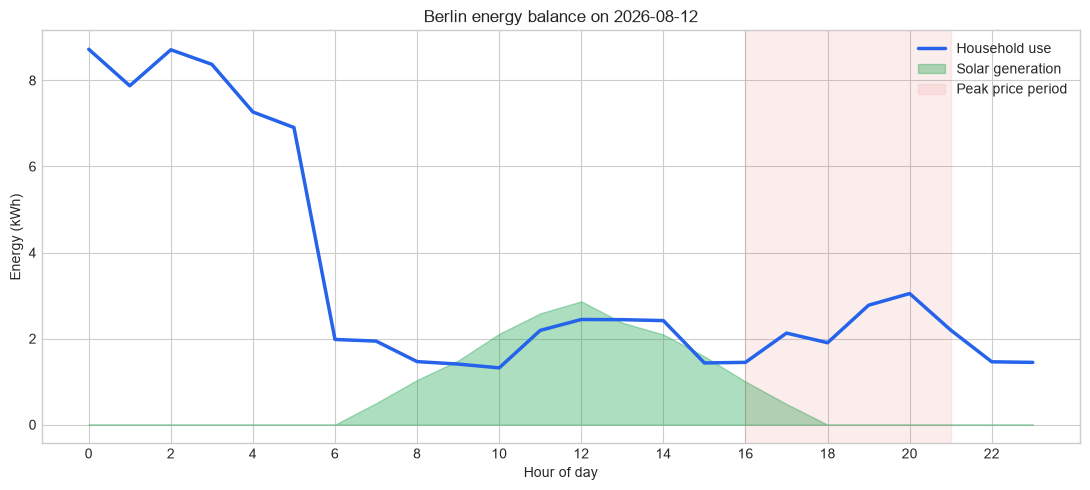

In [3]:
hours = list(range(24))
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hours, hourly_usage.values, color='#2563eb', linewidth=2.5, label='Household use')
ax.fill_between(hours, hourly_solar.values, color='#16a34a', alpha=0.35, label='Solar generation')
ax.axvspan(16, 21, color='#dc2626', alpha=0.08, label='Peak price period')
ax.set(title=f'Berlin energy balance on {latest_date}', xlabel='Hour of day', ylabel='Energy (kWh)')
ax.set_xticks(range(0, 24, 2))
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'energy_balance.png', dpi=160)
plt.show()


## Price windows and device costs

**How to read:** the price chart highlights low cost and peak periods, while the device chart shows which category has the biggest cost reduction opportunity.

**What this shows:** price timing and the EV profile are the largest levers before changing comfort settings.

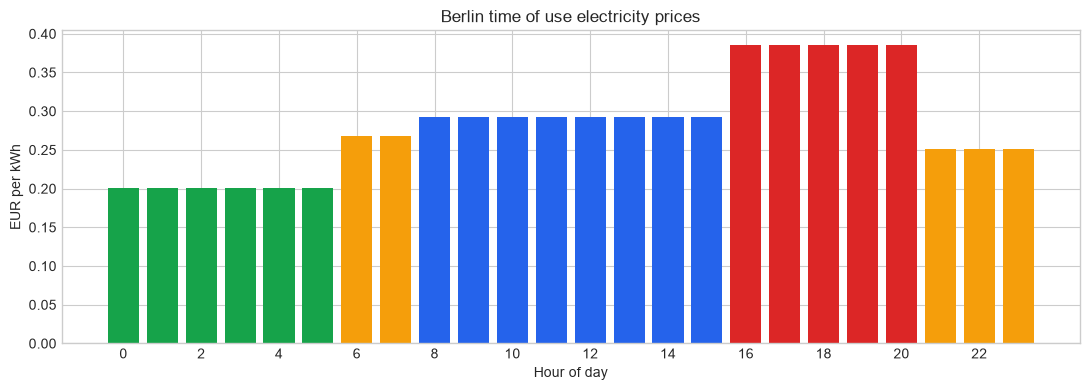

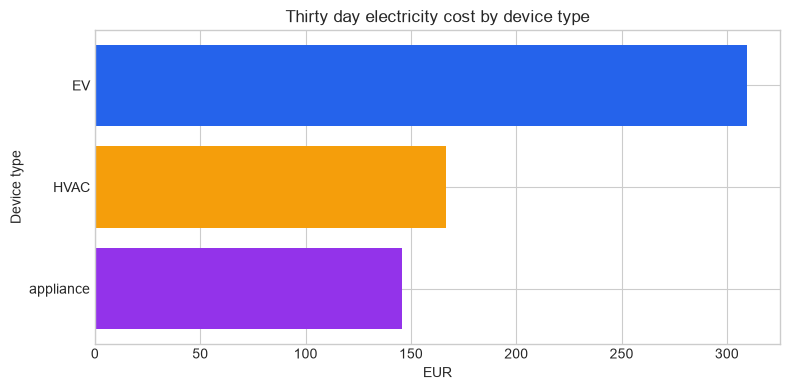

In [4]:
rates = pd.DataFrame(prices['hourly_rates'])
period_colors = {'off_peak': '#16a34a', 'shoulder': '#f59e0b', 'standard': '#2563eb', 'peak': '#dc2626'}
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(rates['hour'], rates['rate_eur_per_kwh'], color=[period_colors[period] for period in rates['period']])
ax.set(title='Berlin time of use electricity prices', xlabel='Hour of day', ylabel='EUR per kWh')
ax.set_xticks(range(0, 24, 2))
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'pricing_windows.png', dpi=160)
plt.show()

device_costs = usage.groupby('device_type')['cost_eur'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(device_costs.index, device_costs.values, color=['#9333ea', '#f59e0b', '#2563eb'])
ax.set(title='Thirty day electricity cost by device type', xlabel='EUR', ylabel='Device type')
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'device_costs.png', dpi=160)
plt.show()


## Personalized tomorrow plan

**How to read:** each bar is a suggested time window. The plan keeps the EV departure time, comfort band, quiet hours, and battery reserve in view.

**What this shows:** the advisor does not simply chase the cheapest rate. It balances solar, price exposure, and household constraints.

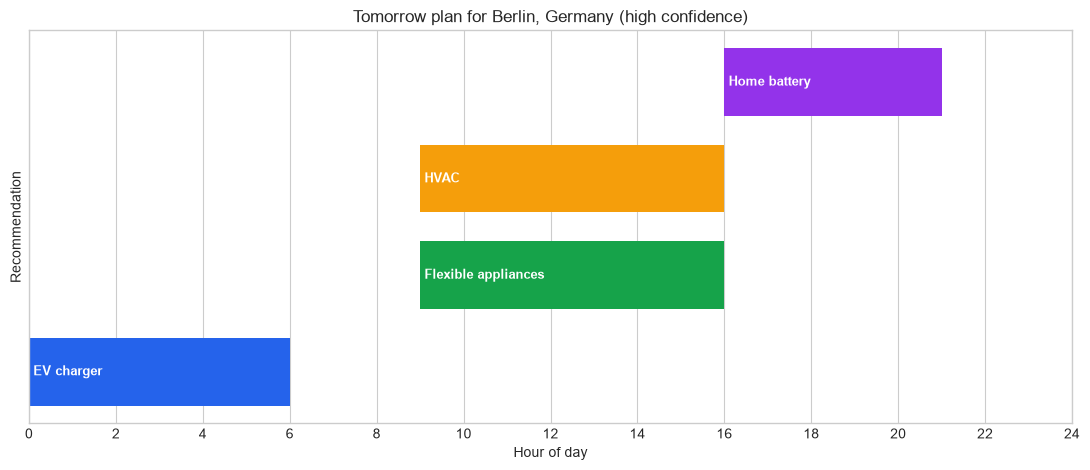

Plan highlights
EV preference: 16.0 kWh before 07:30
Estimated flexible load solar use: 10.5 kWh
Estimated avoided emissions: 2.1 kg CO2e
Assumptions:
- Solar energy is estimated from forecast radiation, not a site specific panel model.
- Carbon impact uses a transparent 350 g CO2e per kWh grid estimate.
- An EV is scheduled before its saved departure time, even when later solar would be stronger.
- The plan recommends schedules only and does not operate devices.


In [5]:
def parse_window(window):
    start, end = window.replace('–', '-').split('-')
    return int(start[:2]), int(end[:2])

fig, ax = plt.subplots(figsize=(11, 4.8))
colors = ['#2563eb', '#16a34a', '#f59e0b', '#9333ea']
for index, item in enumerate(tomorrow_plan['plan']):
    start, end = parse_window(item['window'])
    ax.broken_barh([(start, end - start)], (index - 0.35, 0.7), facecolors=colors[index])
    ax.text(start + 0.1, index, item['device'], va='center', color='white', fontsize=9, fontweight='bold')
ax.set(title=f"Tomorrow plan for {preferences['location']} ({tomorrow_plan['confidence']} confidence)", xlabel='Hour of day', ylabel='Recommendation')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_yticks([])
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'tomorrow_plan.png', dpi=160)
plt.show()

impact = tomorrow_plan['estimated_impact']['carbon']
print('Plan highlights')
print(f"EV preference: {preferences['ev']['target_charge_kwh']} kWh before {preferences['ev']['departure_time']}")
print(f"Estimated flexible load solar use: {tomorrow_plan['estimated_impact']['estimated_flexible_load_solar_kwh']} kWh")
print(f"Estimated avoided emissions: {impact['estimated_avoided_kg_co2e']} kg CO2e")
print('Assumptions:', *tomorrow_plan['assumptions'], sep='\n- ')
